In [14]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Laoding the images

path = '../raw_data/images_split/train'

# Image size and batch size
img_height, img_width = 128, 128
batch_size = 32

# Loading dataset and split into training and validation sets
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Retrieve class names
class_names = train_dataset.class_names
print(f"Class names: {class_names}")

Found 2640 files belonging to 12 classes.
Using 2112 files for training.


I0000 00:00:1736919255.330452    2030 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-15 07:34:15.331068: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 2640 files belonging to 12 classes.
Using 528 files for validation.
Class names: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']


2025-01-15 07:34:16.272924: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


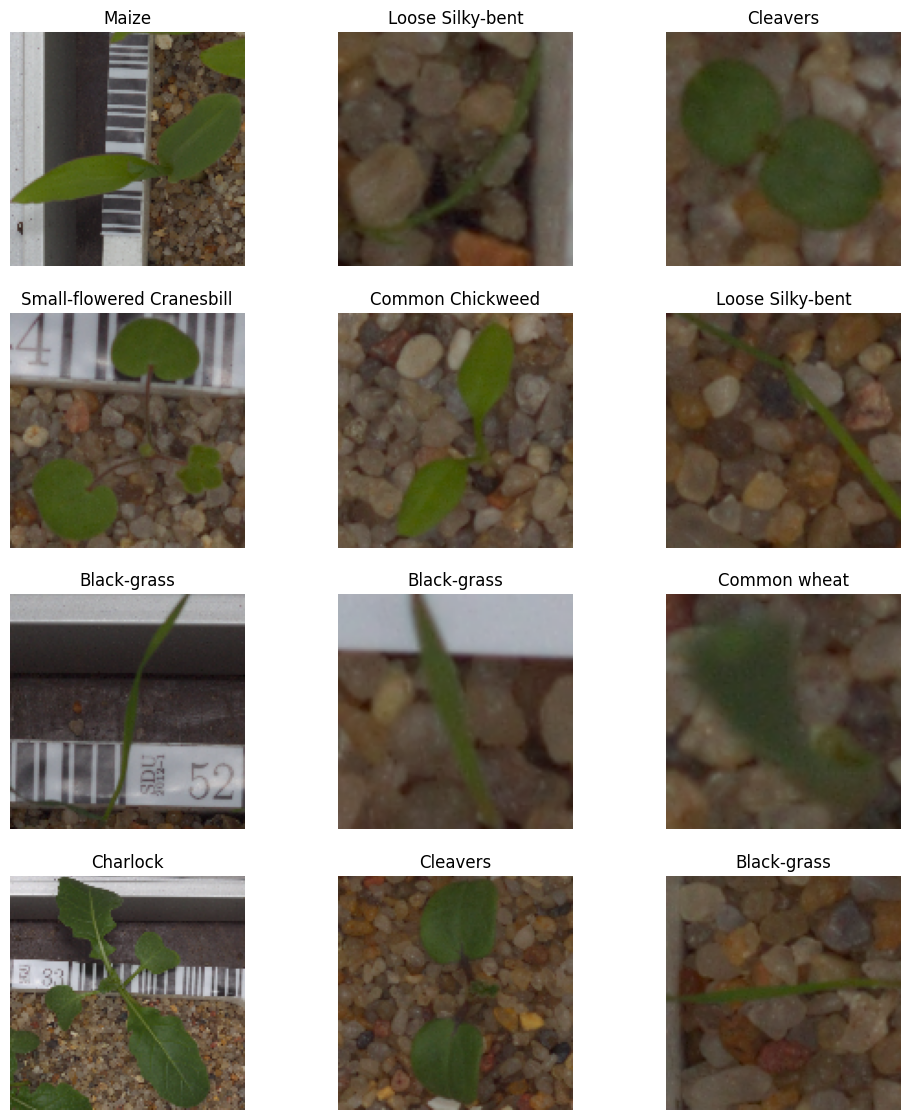

In [ ]:
# Visualizing the dataset

plt.figure(figsize=(12, 14))
for images, labels in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(4, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [4]:
# Augmentation tf.layer

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2)
])

In [5]:
# Color segmintaion tf.layer

# Reference color in CIELUV space
reference_color = tf.convert_to_tensor([35.0, -13.0, 37.0], dtype=tf.float32)

# CIELUV Segmintaion Layer class
class CIELUVSegmintaion(tf.keras.layers.Layer):
    def __init__(self, reference_color, threshold=32.0, **kwargs):
        super(CIELUVSegmintaion, self).__init__(**kwargs)
        self.reference_color = tf.convert_to_tensor(reference_color, dtype=tf.float32)
        self.threshold = threshold

    def rgb_to_xyz(self, rgb):
        rgb = tf.clip_by_value(rgb, 0.0, 1.0)
        mask = (rgb > 0.04045)
        rgb = tf.where(mask, tf.pow((rgb + 0.055) / 1.055, 2.4), rgb / 12.92)
        rgb = rgb * 100.0
        x = 0.4124 * rgb[..., 0] + 0.3576 * rgb[..., 1] + 0.1805 * rgb[..., 2]
        y = 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]
        z = 0.0193 * rgb[..., 0] + 0.1192 * rgb[..., 1] + 0.9505 * rgb[..., 2]
        return tf.stack([x, y, z], axis=-1)

    def xyz_to_cieluv(self, xyz):
        ref_x = 95.047
        ref_y = 100.000
        ref_z = 108.883
        x, y, z = xyz[..., 0] / ref_x, xyz[..., 1] / ref_y, xyz[..., 2] / ref_z
        mask = (y > 0.008856)
        L = tf.where(mask, 116.0 * tf.pow(y, 1/3) - 16.0, 903.3 * y)
        u_prime = 4 * x / (x + 15 * y + 3 * z + 1e-7)
        v_prime = 9 * y / (x + 15 * y + 3 * z + 1e-7)
        u_ref = 4 * ref_x / (ref_x + 15 * ref_y + 3 * ref_z)
        v_ref = 9 * ref_y / (ref_x + 15 * ref_y + 3 * ref_z)
        u = 13 * L * (u_prime - u_ref)
        v = 13 * L * (v_prime - v_ref)
        return tf.stack([L, u, v], axis=-1)

    def call(self, inputs):
        inputs = inputs / 255.0
        xyz_images = self.rgb_to_xyz(inputs)
        cieluv_images = self.xyz_to_cieluv(xyz_images)
        delta = cieluv_images - self.reference_color
        distance = tf.sqrt(tf.reduce_sum(tf.square(delta), axis=-1, keepdims=True))

        # Mask
        mask = distance < self.threshold
        mask = tf.tile(mask, [1, 1, 1, 3])
        output = tf.where(mask, inputs, tf.zeros_like(inputs))

        return output

Original images shape: (32, 128, 128, 3)
Transformed images shape: (32, 128, 128, 3)


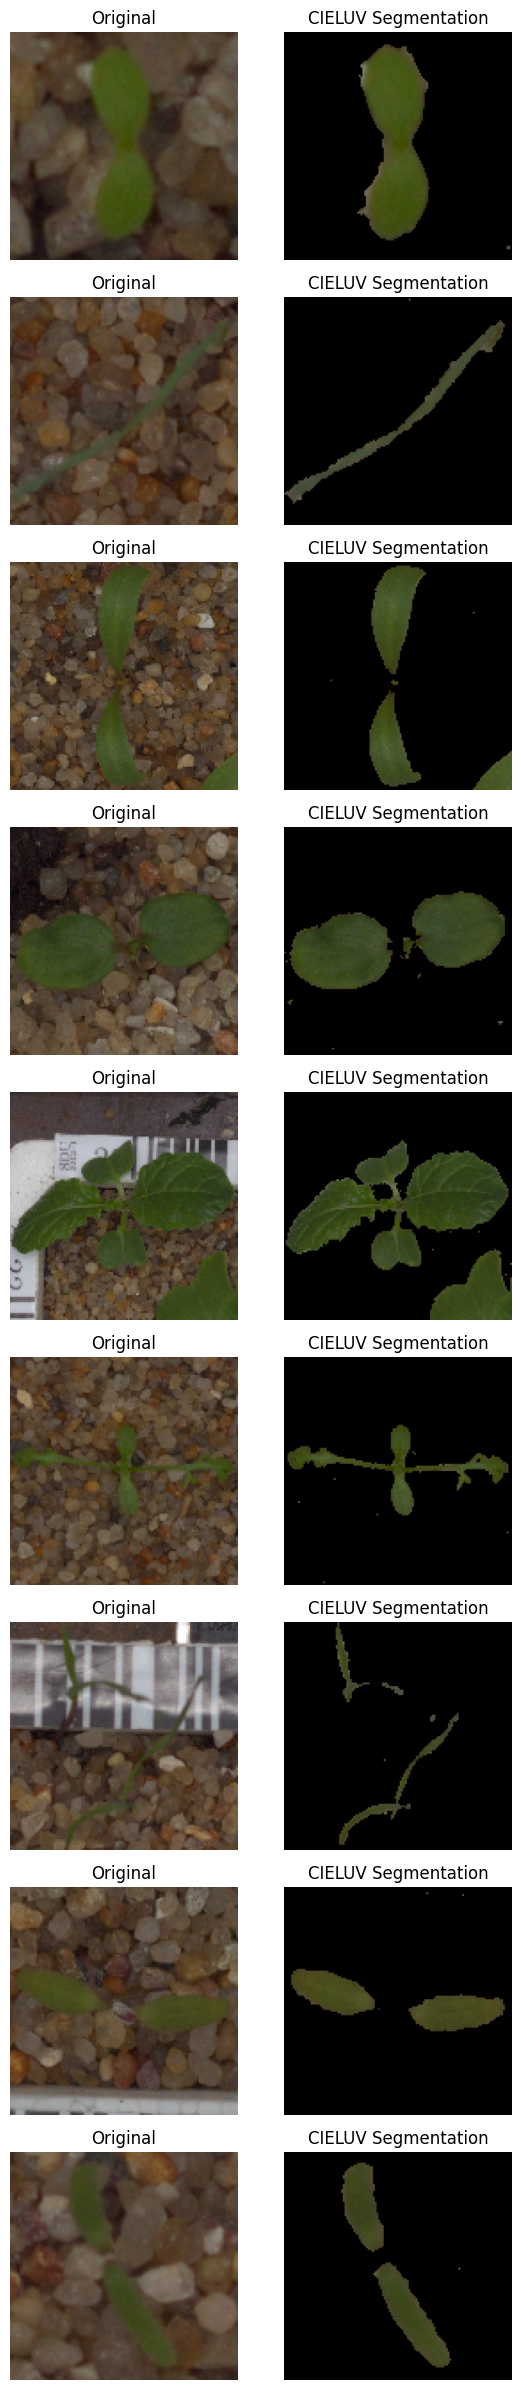

2025-01-15 10:56:03.405726: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
# Visualzing the color segmintation

def visualize_cieluv_output(dataset, cieluv_layer):

    # Taking one batch of images from the dataset
    for images, _ in dataset.take(1):

        # Applying the CIELUV layer
        transformed_images = cieluv_layer(images)

        plt.figure(figsize=(6, 24))

        for i in range(min(9, images.shape[0])):

            # Original image
            ax = plt.subplot(9, 2, 2 * i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title("Original")
            plt.axis("off")

            # Transformed image
            ax = plt.subplot(9, 2, 2 * i + 2)
            plt.imshow(np.squeeze(transformed_images[i].numpy()))
            plt.title("CIELUV Segmentation")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

cieluv_layer = CIELUVSegmintaion(reference_color=reference_color)


visualize_cieluv_output(train_dataset, cieluv_layer)

In [ ]:
# Model

def create_cnn_model(input_shape, num_classes):
    model = models.Sequential()

    # Normalization layer
    model.add(tf.keras.layers.Rescaling(scale=1.0/255, input_shape=input_shape))

    # Data augmentation layer
    model.add(data_augmentation)

    # CIELUV Segmentation layer
    CIELUVSegmintaion(reference_color=reference_color)

    # CNN block 1
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.1))

    # CNN block 2
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    # CNN block 3
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2))

    # CNN block 4
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.3))

    # Dense block (vector)
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


input_shape = (128, 128, 3)
num_classes = 12

cnn_model = create_cnn_model(input_shape, num_classes)
cnn_model.compile(optimizer= 'adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


cnn_model.summary()

/home/dorwein/.pyenv/versions/3.10.6/envs/ai_weeder/lib/python3.10/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,686,412 (6.43 MB)

 Trainable params: 1,685,900 (6.43 MB)

 Non-trainable params: 512 (2.00 KB)

In [8]:
# Training

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=140,
    verbose=1,
    callbacks=[es, lr_scheduler],
)


Epoch 1/140
66/66 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.0885 - loss: 2.5879 - val_accuracy: 0.0682 - val_loss: 2.4864 - learning_rate: 0.0010
Epoch 2/140
66/66 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.1061 - loss: 2.4753 - val_accuracy: 0.1080 - val_loss: 2.4793 - learning_rate: 0.0010
Epoch 3/140
66/66 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.1367 - loss: 2.3607 - val_accuracy: 0.1932 - val_loss: 2.4014 - learning_rate: 0.0010
Epoch 4/140
66/66 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.2101 - loss: 2.0100 - val_accuracy: 0.2500 - val_loss: 2.2582 - learning_rate: 0.0010
Epoch 5/140
66/66 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.2754 - loss: 1.8919 - val_accuracy: 0.2083 - val_loss: 2.1528 - learning_rate: 0.0010
Epoch 6/140
66/66 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.3484 - loss: 1.7483 - val_accuracy: 0.2898 - val_loss: 2.0300 - learning_rate: 0.0010
Epoch 7/140
66/66 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.3499 - loss: 1.7206 - val_acc

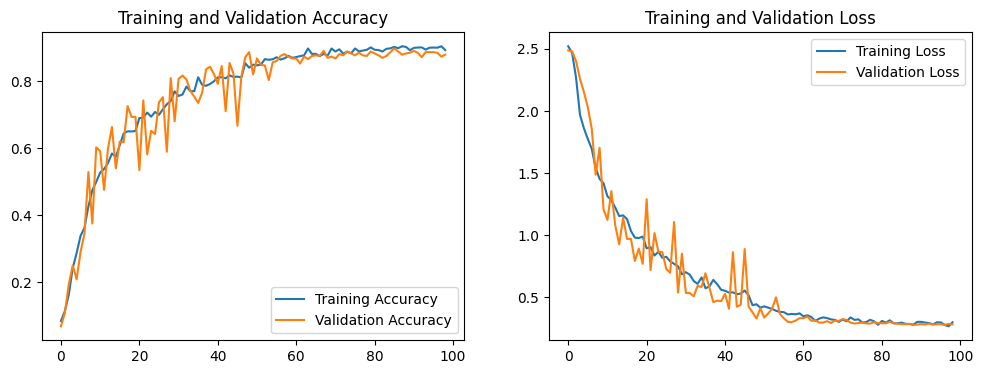

In [9]:
# Metrics from the history
acc = history.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', [])
loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])

# Number of epochs actually trained
epochs_trained = len(acc)

# Plotting training and validation accuracy

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(epochs_trained), acc, label='Training Accuracy')
plt.plot(range(epochs_trained), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(epochs_trained), loss, label='Training Loss')
plt.plot(range(epochs_trained), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [11]:
# Evaluating on validation
evaluate = cnn_model.evaluate(val_dataset)
evaluate

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 246ms/step - accuracy: 0.9046 - loss: 0.2471


[0.27923670411109924, 0.8825757503509521]

In [ ]:
# Evaluating on test
test_dir = '../raw_data/images_split/test'

batch_size = 10

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

print(f"Class names: {test_dataset.class_names}")

predictions = cnn_model.predict(test_dataset)
predicted_labels = tf.argmax(predictions, axis=1)
true_labels = tf.concat([y for x, y in test_dataset], axis=0)

test_loss, test_accuracy = cnn_model.evaluate(test_dataset)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Found 384 files belonging to 12 classes.
Class names: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8969 - loss: 0.3134
Test Loss: 0.23849399387836456
Test Accuracy: 0.9166666865348816


In [15]:
# Classification report
print(classification_report(true_labels.numpy(), predicted_labels.numpy(), target_names=test_dataset.class_names))

                           precision    recall  f1-score   support

              Black-grass       0.81      0.81      0.81        32
                 Charlock       0.94      0.97      0.95        32
                 Cleavers       0.83      0.91      0.87        32
         Common Chickweed       1.00      0.97      0.98        32
             Common wheat       0.88      0.94      0.91        32
                  Fat Hen       1.00      0.84      0.92        32
         Loose Silky-bent       0.84      0.84      0.84        32
                    Maize       0.94      1.00      0.97        32
        Scentless Mayweed       0.89      0.97      0.93        32
          Shepherds Purse       0.97      0.88      0.92        32
Small-flowered Cranesbill       0.94      0.97      0.95        32
               Sugar beet       1.00      0.91      0.95        32

                 accuracy                           0.92       384
                macro avg       0.92      0.92      0.92    

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 [Text(0.5, 0, 'Black-grass'),
  Text(1.5, 0, 'Charlock'),
  Text(2.5, 0, 'Cleavers'),
  Text(3.5, 0, 'Common Chickweed'),
  Text(4.5, 0, 'Common wheat'),
  Text(5.5, 0, 'Fat Hen'),
  Text(6.5, 0, 'Loose Silky-bent'),
  Text(7.5, 0, 'Maize'),
  Text(8.5, 0, 'Scentless Mayweed'),
  Text(9.5, 0, 'Shepherds Purse'),
  Text(10.5, 0, 'Small-flowered Cranesbill'),
  Text(11.5, 0, 'Sugar beet')])

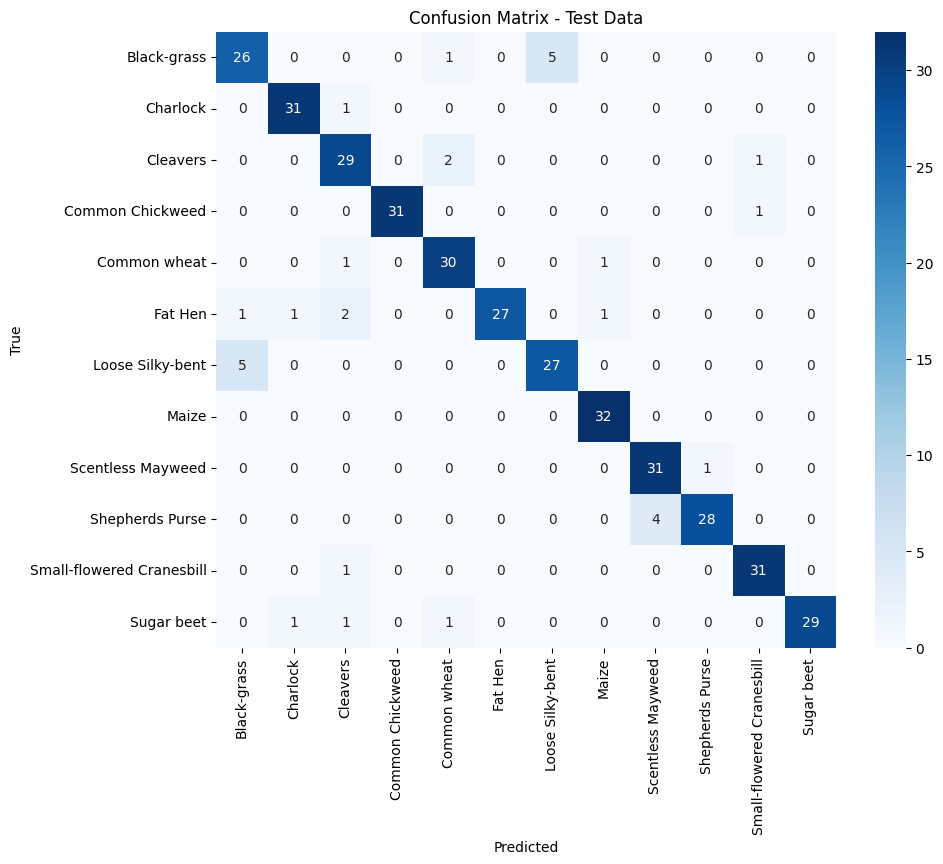

In [ ]:
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=test_dataset.class_names, yticklabels=test_dataset.class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test Data')
plt.xticks(rotation=90)

In [10]:
# Saving the model
cnn_model.save('../models/model_cnn_color_seg.keras')